# Anscombe's Quartet Analysis

**Anscombe's Quartet** (Francis Anscombe, 1973) is a classic dataset designed to demonstrate
the importance of data visualization. It consists of four datasets — I, II, III, and IV —
each containing 11 (x, y) pairs.

The datasets are constructed so that they share nearly identical descriptive statistics:
mean, variance, correlation, and linear regression coefficients. Yet when plotted, each
dataset reveals a strikingly different underlying structure.

This notebook:
1. Computes descriptive statistics to confirm the "statistical similarity"
2. Reveals the structural differences through multiple visualizations
3. Demonstrates why visualizing data is essential before drawing conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

In [2]:
# Load the dataset
df = pd.read_csv('anscombe_quartet.tsv', sep='\t')

# Validate
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Datasets: {df['dataset'].unique().tolist()}")
print(f"Counts per dataset:")
print(df['dataset'].value_counts().sort_index())
print()
print(df.head(10))

Shape: (44, 3)
Columns: ['dataset', 'x', 'y']
Datasets: ['I', 'II', 'III', 'IV']
Counts per dataset:
dataset
I      11
II     11
III    11
IV     11
Name: count, dtype: int64

  dataset   x      y
0       I  10   8.04
1       I   8   6.95
2       I  13   7.58
3       I   9   8.81
4       I  11   8.33
5       I  14   9.96
6       I   6   7.24
7       I   4   4.26
8       I  12  10.84
9       I   7   4.82


In [3]:
# Define color map used throughout
COLORS = {'I': 'steelblue', 'II': 'darkorange', 'III': 'forestgreen', 'IV': 'crimson'}
DATASETS = ['I', 'II', 'III', 'IV']

# Compute per-dataset statistics
rows = []
for ds in DATASETS:
    sub = df[df['dataset'] == ds]
    x, y = sub['x'].values, sub['y'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    rows.append({
        'Dataset': ds,
        'n': len(x),
        'mean(x)': round(x.mean(), 4),
        'mean(y)': round(y.mean(), 4),
        'std(x)':  round(x.std(ddof=1), 4),
        'std(y)':  round(y.std(ddof=1), 4),
        'r':       round(r_value, 4),
        'R²':      round(r_value**2, 4),
        'slope':   round(slope, 4),
        'intercept': round(intercept, 4),
        'min(x)':  x.min(),
        'max(x)':  x.max(),
        'median(x)': np.median(x),
        'min(y)':  round(y.min(), 4),
        'max(y)':  round(y.max(), 4),
        'median(y)': round(np.median(y), 4),
    })

stats_df = pd.DataFrame(rows).set_index('Dataset')

# Style: highlight columns where values are near-identical (std < 0.01)
near_identical_cols = [c for c in stats_df.columns
                       if stats_df[c].std() < 0.01]
print(f"Near-identical columns: {near_identical_cols}")

def highlight_near_identical(col):
    if col.name in near_identical_cols:
        return ['background-color: #d4edda'] * len(col)
    return [''] * len(col)

styled = (stats_df.style
          .apply(highlight_near_identical)
          .set_caption("Descriptive Statistics — green = near-identical across datasets")
          .format(precision=4))
styled

Near-identical columns: ['n', 'mean(x)', 'mean(y)', 'std(x)', 'std(y)', 'r', 'R²', 'slope', 'intercept']


,n,mean(x),mean(y),std(x),std(y),r,R²,slope,intercept,min(x),max(x),median(x),min(y),max(y),median(y)
Dataset,,,,,,,,,,,,,,,
I,11,9.0000,7.5009,3.3166,2.0316,0.8164,0.6665,0.5001,3.0001,4,14,9.0000,4.2600,10.8400,7.5800
II,11,9.0000,7.5009,3.3166,2.0317,0.8162,0.6662,0.5000,3.0009,4,14,9.0000,3.1000,9.2600,8.1400
III,11,9.0000,7.5000,3.3166,2.0304,0.8163,0.6663,0.4997,3.0025,4,14,9.0000,5.3900,12.7400,7.1100
IV,11,9.0000,7.5009,3.3166,2.0306,0.8165,0.6667,0.4999,3.0017,8,19,8.0000,5.2500,12.5000,7.0400


## The Statistical Illusion

Despite sharing **nearly identical statistics** — mean, standard deviation, correlation,
and OLS regression coefficients — the four datasets tell very different stories
when visualized. The next chart makes this concrete by placing all key statistics
side by side before revealing the structural differences.

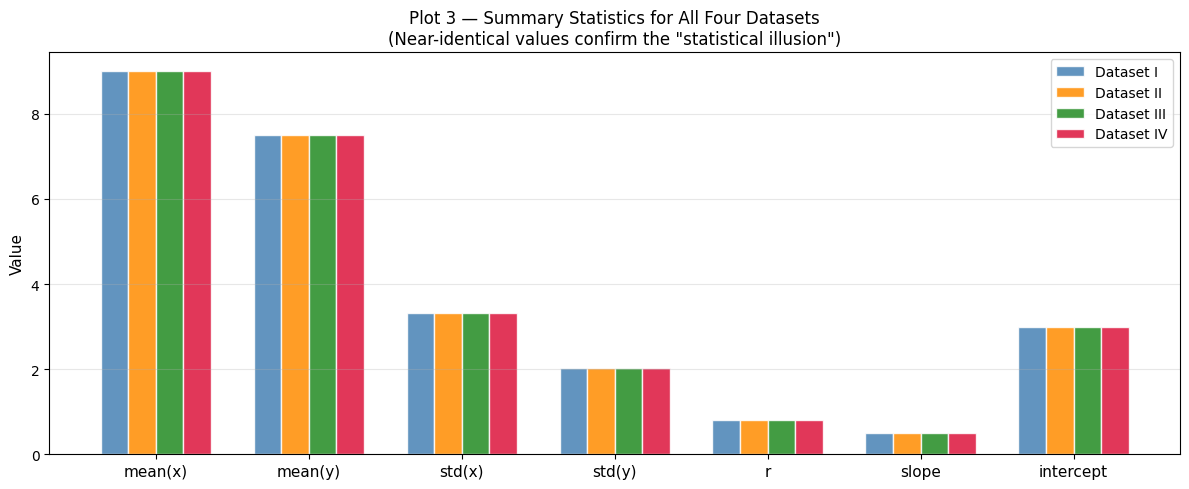

Saved: plot_3.png


In [4]:
# Plot 3: Grouped bar chart of summary statistics
stat_keys = ['mean(x)', 'mean(y)', 'std(x)', 'std(y)', 'r', 'slope', 'intercept']
stat_labels = ['mean(x)', 'mean(y)', 'std(x)', 'std(y)', 'r', 'slope', 'intercept']

x_pos = np.arange(len(stat_keys))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(12, 5))
for i, ds in enumerate(DATASETS):
    vals = [stats_df.loc[ds, k] for k in stat_keys]
    bars = ax.bar(x_pos + offsets[i] * width, vals, width,
                  label=f'Dataset {ds}', color=COLORS[ds], alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(stat_labels, fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title("Plot 3 — Summary Statistics for All Four Datasets\n"
             "(Near-identical values confirm the \"statistical illusion\")", fontsize=12)
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_3.png', dpi=150)
plt.show()
print("Saved: plot_3.png")

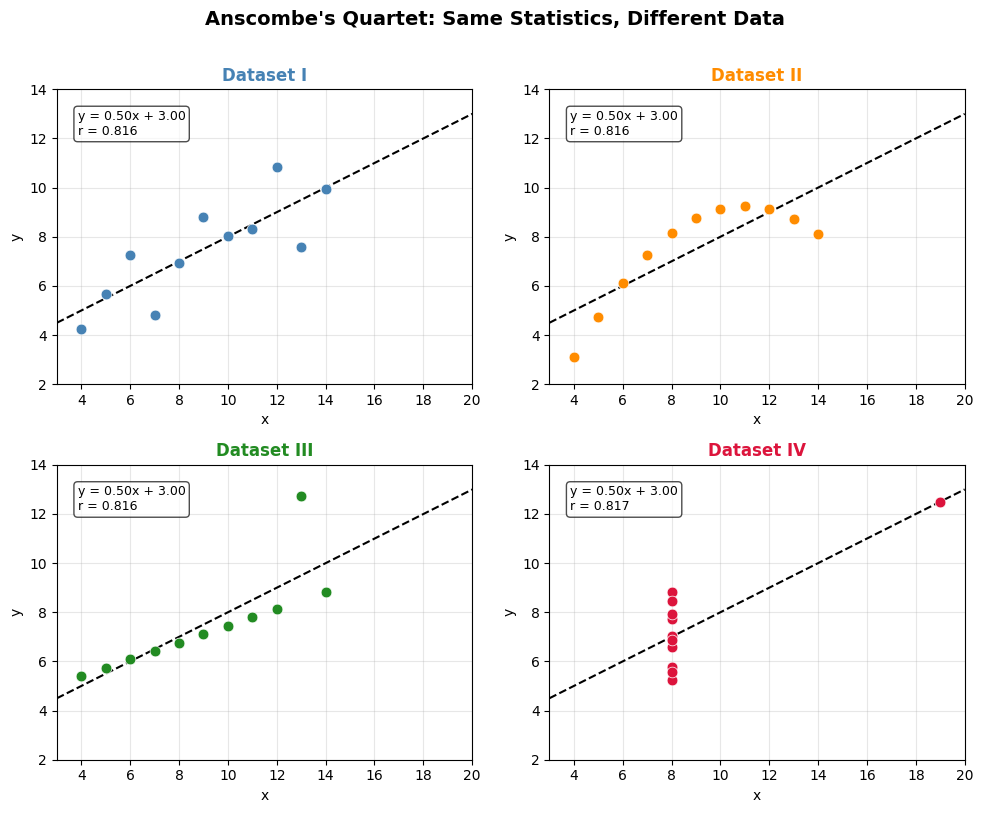

Saved: plot_1.png


In [5]:
# Plot 1: 2×2 Scatter Grid with regression lines
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, ds in enumerate(DATASETS):
    ax = axes[i]
    sub = df[df['dataset'] == ds]
    x, y = sub['x'].values, sub['y'].values
    slope, intercept, r_value, _, _ = stats.linregress(x, y)

    # Scatter
    ax.scatter(x, y, color=COLORS[ds], s=60, zorder=3, edgecolors='white', linewidths=0.5)

    # Regression line over x range
    x_line = np.linspace(3, 20, 100)
    ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5,
            linestyle='--', zorder=2)

    # Shared axis limits
    ax.set_xlim(3, 20)
    ax.set_ylim(2, 14)

    # Annotation
    ax.text(0.05, 0.93,
            f'y = {slope:.2f}x + {intercept:.2f}\nr = {r_value:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_title(f'Dataset {ds}', fontsize=12, color=COLORS[ds], fontweight='bold')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle("Anscombe's Quartet: Same Statistics, Different Data",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_1.png")

## Structural Differences

The four scatter plots reveal fundamentally different data structures:

- **Dataset I** — A classic linear relationship with typical random scatter around the line.
- **Dataset II** — A clear parabolic (curved) relationship; a linear model is the wrong fit entirely.
- **Dataset III** — Mostly linear, but one outlier (the point at x=13) exerts extreme leverage.
  Remove it and the regression slope would shift dramatically.
- **Dataset IV** — A pathological case: all x values are identical at x=8 except for one
  high-leverage point at x=19 which alone determines the regression line slope.

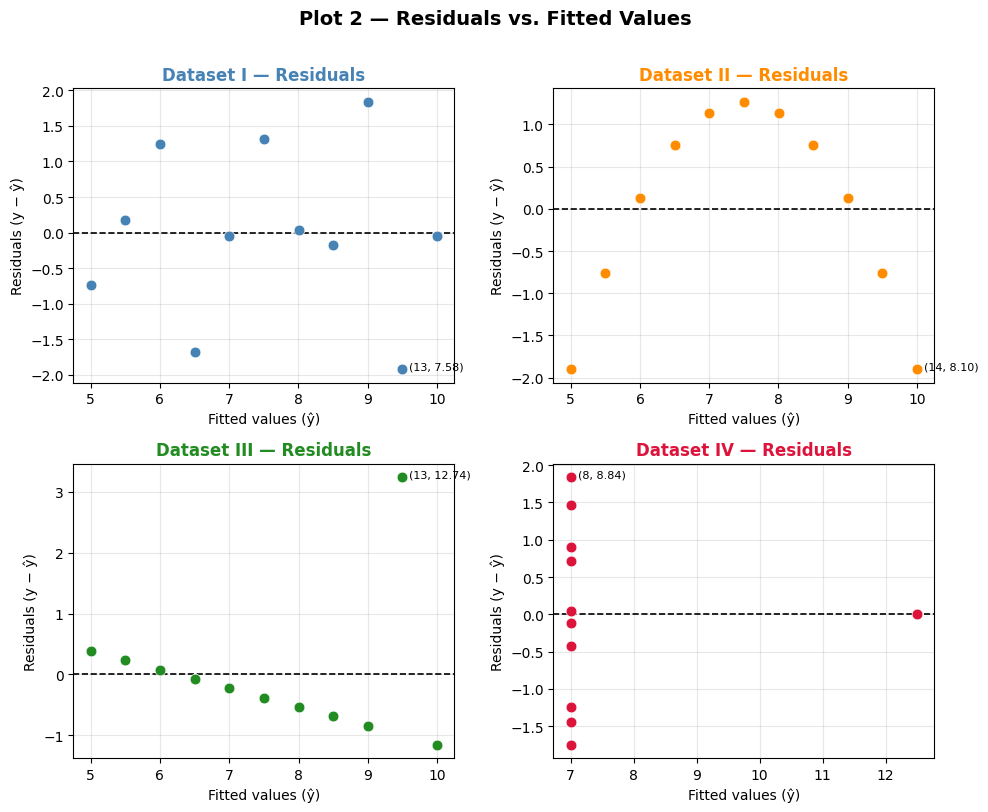

Saved: plot_2.png


In [6]:
# Plot 2: 2×2 Residual Plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, ds in enumerate(DATASETS):
    ax = axes[i]
    sub = df[df['dataset'] == ds]
    x, y = sub['x'].values, sub['y'].values
    slope, intercept, r_value, _, _ = stats.linregress(x, y)

    fitted = slope * x + intercept
    residuals = y - fitted

    ax.scatter(fitted, residuals, color=COLORS[ds], s=60, zorder=3,
               edgecolors='white', linewidths=0.5)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'Dataset {ds} — Residuals', fontsize=12,
                 color=COLORS[ds], fontweight='bold')
    ax.set_xlabel('Fitted values (ŷ)', fontsize=10)
    ax.set_ylabel('Residuals (y − ŷ)', fontsize=10)
    ax.grid(alpha=0.3)

    # Annotate max residual
    max_idx = np.argmax(np.abs(residuals))
    ax.annotate(f'  ({x[max_idx]:.0f}, {y[max_idx]:.2f})',
                xy=(fitted[max_idx], residuals[max_idx]),
                fontsize=8, color='black')

fig.suptitle("Plot 2 — Residuals vs. Fitted Values",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_2.png")

## Residual Interpretation

Residual plots expose patterns that the scatter grid only hints at:

- **Dataset I** — Residuals appear random and evenly spread around zero. The linear model is appropriate.
- **Dataset II** — A clear parabolic arc in the residuals confirms systematic model misspecification;
  a quadratic term should be included.
- **Dataset III** — One large positive residual (the outlier at x=13, y=12.74) dominates. The
  remaining points have near-zero residuals because the outlier has pulled the regression line toward it.
- **Dataset IV** — Because all x values except one are identical, all fitted values are identical
  (except for the leverage point), producing a vertical cluster of residuals at a single fitted value.

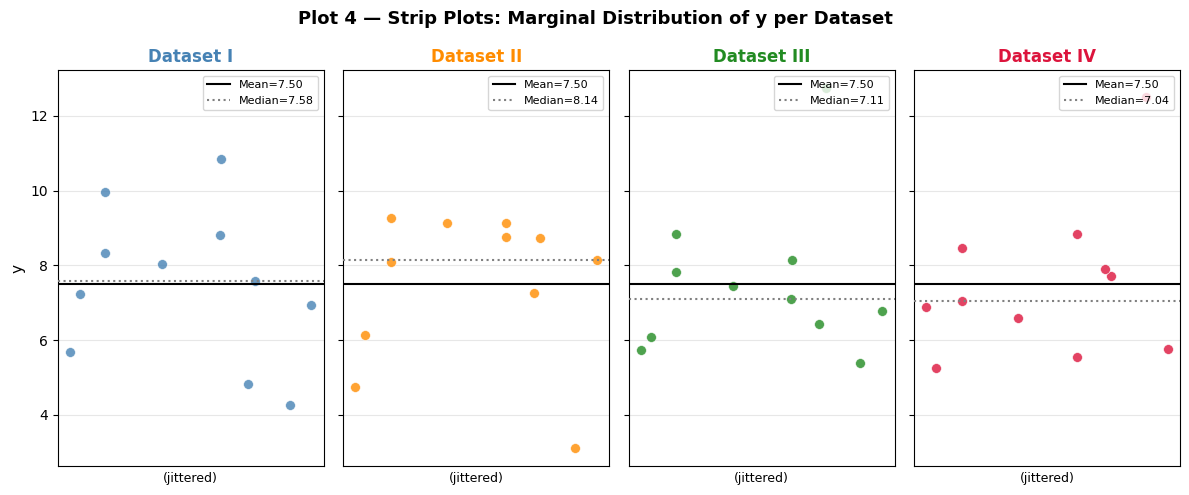

Saved: plot_4.png


In [7]:
# Plot 4: Strip plots of y by dataset
fig, axes = plt.subplots(1, 4, figsize=(12, 5), sharey=True)

for i, ds in enumerate(DATASETS):
    ax = axes[i]
    sub = df[df['dataset'] == ds]
    y = sub['y'].values

    # Jittered x positions for strip plot
    np.random.seed(42)
    x_jitter = np.random.uniform(-0.15, 0.15, size=len(y))

    ax.scatter(x_jitter, y, color=COLORS[ds], s=50, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=3)

    # Mean and median markers
    mean_y = y.mean()
    median_y = np.median(y)
    ax.axhline(mean_y, color='black', linewidth=1.5, linestyle='-',
               label=f'Mean={mean_y:.2f}', zorder=4)
    ax.axhline(median_y, color='gray', linewidth=1.5, linestyle=':',
               label=f'Median={median_y:.2f}', zorder=4)

    ax.set_title(f'Dataset {ds}', fontsize=12, color=COLORS[ds], fontweight='bold')
    ax.set_xticks([])
    ax.set_xlabel('(jittered)', fontsize=9)
    if i == 0:
        ax.set_ylabel('y', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Plot 4 — Strip Plots: Marginal Distribution of y per Dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_4.png")

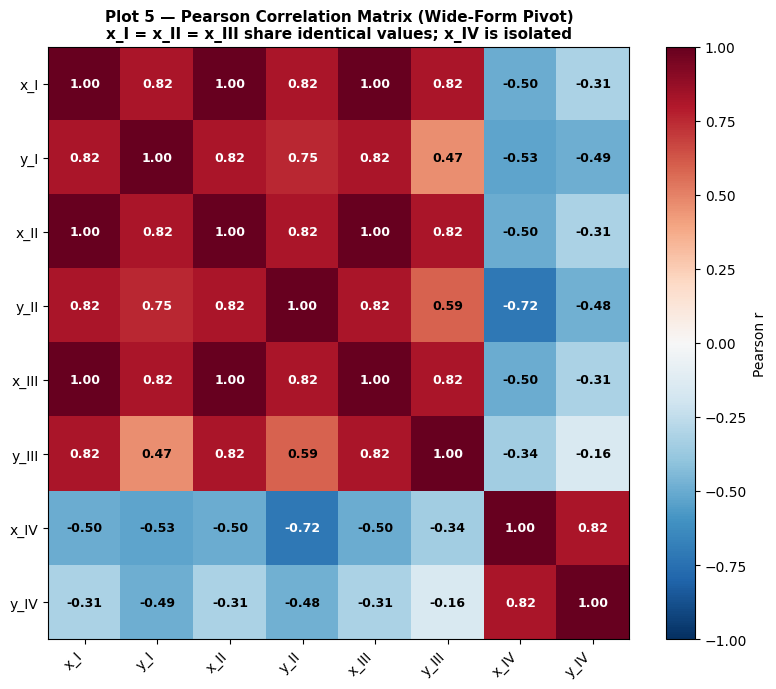

Saved: plot_5.png


In [8]:
# Plot 5: Correlation heatmap (wide-form pivot)
wide_parts = []
for ds in DATASETS:
    sub = df[df['dataset'] == ds][['x', 'y']].reset_index(drop=True)
    sub.columns = [f'x_{ds}', f'y_{ds}']
    wide_parts.append(sub)

wide_df = pd.concat(wide_parts, axis=1)
corr_matrix = wide_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 7))
cols = corr_matrix.columns.tolist()
n = len(cols)
data = corr_matrix.values

im = ax.imshow(data, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(cols, fontsize=10)

# Annotate cells
for row in range(n):
    for col in range(n):
        val = data[row, col]
        text_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight='bold')

ax.set_title("Plot 5 — Pearson Correlation Matrix (Wide-Form Pivot)\n"
             "x_I = x_II = x_III share identical values; x_IV is isolated",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_5.png")

## Conclusions

1. **Summary statistics alone are insufficient for understanding data.**
   All four datasets share nearly identical means, standard deviations, correlations,
   and regression coefficients — yet they represent fundamentally different phenomena.
   Dataset I is genuinely linear; Dataset II is curved; Dataset III has an outlier;
   Dataset IV is a degenerate case driven by a single leverage point.

2. **Always visualize before modeling.**
   Anscombe's Quartet is a canonical argument for exploratory data analysis (EDA).
   Scatter plots, residual plots, and marginal distributions together reveal structure
   that summary statistics conceal. Applying a linear model to Dataset II or IV
   would yield misleading conclusions despite a "good" R².

3. **Residual plots are essential regression diagnostics.**
   The parabolic residuals of Dataset II, the single dominant residual of Dataset III,
   and the vertical cluster of Dataset IV each signal a distinct modeling failure —
   none of which is visible from the regression equation alone.